In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, kstest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from IPython.display import display
import warnings
import joblib
import gc

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ Tahap 1: Semua library berhasil diimport!")

✅ Tahap 1: Semua library berhasil diimport!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# TAHAP 2 — IMPORT DATASET
# ============================================================
print("⏳ Membaca dataset BAF (Base.csv)...")
df = pd.read_csv('/content/drive/MyDrive/Data Analyst - PBL Data Science/Base.csv')

print("✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris : {df.shape[0]:,}")
print(f"   Jumlah kolom : {df.shape[1]}")
print(f"   Penggunaan memori: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")

⏳ Membaca dataset BAF (Base.csv)...
✅ Dataset berhasil dimuat!
   Jumlah baris : 1,000,000
   Jumlah kolom : 32
   Penggunaan memori: 0.48 GB


In [ ]:
# TAHAP 3 — MEMBACA DATASET (Gambaran Awal)
print("\n🔍 Gambaran Awal Dataset:")
display(df.head(3))


🔍 Gambaran Awal Dataset:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3000,0.9865,-1,25,40,0.0067,102.4537,AA,1059,13096.0350,7850.9550,6742.0806,5,5,CB,163,1,BC,0,1,9,0,1500.0000,0,INTERNET,16.2248,linux,1,1,0,0
1,0,0.8000,0.6174,-1,89,20,0.0101,-0.8496,AD,1658,9223.2834,5745.2515,5941.6649,3,18,CA,154,1,BC,1,1,2,0,1500.0000,0,INTERNET,3.3639,other,1,1,0,0
2,0,0.8000,0.9967,9,14,40,0.0123,-1.4904,AB,1095,4471.4721,5471.9890,5992.5551,15,11,CA,89,1,BC,0,1,30,0,200.0000,0,INTERNET,22.7306,windows,0,1,0,0


In [ ]:
# TAHAP 4 — df.info()
print("\nℹ️ Informasi Tipe Data dan Nilai Null:")
df.info()


ℹ️ Informasi Tipe Data dan Nilai Null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11

In [ ]:
# TAHAP 5 — df.shape (Dimensi Dataset)
baris, kolom = df.shape
print(f"\n📐 Dimensi Dataset: {baris:,} baris x {kolom} kolom")


📐 Dimensi Dataset: 1,000,000 baris x 32 kolom


In [ ]:
# TAHAP 6 — META DATASET (Kamus Fitur BAF)
meta = pd.DataFrame({
    'Nama Kolom': df.columns,
    'Tipe Data Asli': df.dtypes.astype(str),
    'Peran / Penjelasan': [
        'Target Biner (0 = Sah, 1 = Penipu)', 'Pendapatan pemohon (Kuantil)', 'Kemiripan nama dan email',
        'Bulan di alamat sebelumnya (-1 = Tidak ada riwayat)', 'Bulan di alamat saat ini',
        'Kelompok usia (Protected Attribute)', 'Selisih hari sejak request', 'Saldo intensi',
        'Tipe pembayaran (Kategorikal)', 'Jumlah ZIP dalam 4 minggu', 'Kecepatan transaksi 6 jam',
        'Kecepatan transaksi 24 jam', 'Kecepatan transaksi 4 minggu', 'Jumlah cabang bank 8 minggu',
        'Email berbeda berdasarkan DOB 4 minggu', 'Status pekerjaan (Protected Attribute/Kategorikal)',
        'Skor risiko kredit', 'Apakah domain email gratis (0/1)', 'Status hunian (Kategorikal)',
        'Nomor telepon rumah valid (0/1)', 'Nomor HP valid (0/1)', 'Usia akun bank lain (bulan)',
        'Punya kartu lain (0/1)', 'Batas kredit diajukan', 'Request dari luar negeri (0/1)',
        'Sumber pendaftaran (Kategorikal)', 'Lama sesi pengisian form (menit)', 'OS Perangkat (Kategorikal)',
        'Sesi dipertahankan tetap hidup (0/1)', 'Email unik di perangkat 8 minggu',
        'Jumlah fraud di perangkat', 'Bulan (0-7, digunakan untuk Temporal Split)'
    ]
})
print("\n📖 Kamus Meta Dataset (NeurIPS 2022):")
display(meta.style.set_properties(**{'text-align': 'left'}))


📖 Kamus Meta Dataset (NeurIPS 2022):


,Nama Kolom,Tipe Data Asli,Peran / Penjelasan
fraud_bool,fraud_bool,int64,"Target Biner (0 = Sah, 1 = Penipu)"
income,income,float64,Pendapatan pemohon (Kuantil)
name_email_similarity,name_email_similarity,float64,Kemiripan nama dan email
prev_address_months_count,prev_address_months_count,int64,Bulan di alamat sebelumnya (-1 = Tidak ada riwayat)
current_address_months_count,current_address_months_count,int64,Bulan di alamat saat ini
customer_age,customer_age,int64,Kelompok usia (Protected Attribute)
days_since_request,days_since_request,float64,Selisih hari sejak request
intended_balcon_amount,intended_balcon_amount,float64,Saldo intensi
payment_type,payment_type,object,Tipe pembayaran (Kategorikal)
zip_count_4w,zip_count_4w,int64,Jumlah ZIP dalam 4 minggu


In [ ]:
# TAHAP 7 — MENAMPILKAN 5 DATA TERATAS
print("\n🔼 5 Data Teratas:")
display(df.head())


🔼 5 Data Teratas:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3000,0.9865,-1,25,40,0.0067,102.4537,AA,1059,13096.0350,7850.9550,6742.0806,5,5,CB,163,1,BC,0,1,9,0,1500.0000,0,INTERNET,16.2248,linux,1,1,0,0
1,0,0.8000,0.6174,-1,89,20,0.0101,-0.8496,AD,1658,9223.2834,5745.2515,5941.6649,3,18,CA,154,1,BC,1,1,2,0,1500.0000,0,INTERNET,3.3639,other,1,1,0,0
2,0,0.8000,0.9967,9,14,40,0.0123,-1.4904,AB,1095,4471.4721,5471.9890,5992.5551,15,11,CA,89,1,BC,0,1,30,0,200.0000,0,INTERNET,22.7306,windows,0,1,0,0
3,0,0.6000,0.4751,11,14,30,0.0070,-1.8631,AB,3483,14431.9936,6755.3445,5970.3368,11,13,CA,90,1,BC,0,1,1,0,200.0000,0,INTERNET,15.2158,linux,1,1,0,0
4,0,0.9000,0.8423,-1,29,40,5.7426,47.1525,AA,2339,7601.5116,5124.0469,5940.7342,1,6,CA,91,0,BC,1,1,26,0,200.0000,0,INTERNET,3.7430,other,0,1,0,0


In [ ]:
# TAHAP 8 — MENAMPILKAN 5 DATA TERAKHIR
print("\n🔽 5 Data Terakhir:")
display(df.tail())


🔽 5 Data Terakhir:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
999995,0,0.8000,0.1247,-1,143,30,0.0513,-0.8262,AB,530,6732.6024,3010.0481,3095.7542,42,8,CA,305,1,BB,1,1,31,0,1500.0000,0,INTERNET,16.9678,other,0,1,0,7
999996,0,0.9000,0.8245,-1,193,30,0.0096,0.0083,AC,408,1574.2933,2716.4958,4286.0890,0,5,CA,235,0,BA,1,1,-1,1,1000.0000,0,INTERNET,1.5041,macintosh,0,1,0,7
999997,0,0.8000,0.1409,-1,202,10,0.0593,50.6100,AA,749,1258.8649,3601.3229,3103.8917,2,3,CA,195,1,BE,0,1,31,0,200.0000,0,INTERNET,16.0686,other,0,1,0,7
999998,0,0.9000,0.0025,52,3,30,0.0234,-1.3134,AB,707,7048.1371,6521.3950,3068.2651,7,8,CA,148,0,BD,0,1,1,0,200.0000,0,INTERNET,1.3787,linux,1,1,0,7
999999,0,0.6000,0.9934,-1,174,30,0.0204,14.9425,AA,655,3737.0765,3135.7881,3051.0033,14,8,CA,100,1,BB,0,1,15,1,200.0000,0,INTERNET,1.9479,other,1,1,0,7


In [ ]:
# TAHAP 9 — KEUNIKAN FITUR KATEGORIKAL
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()
print(f"📊 Kolom kategorikal terdeteksi: {kolom_kategorikal}\n")

for col in kolom_kategorikal:
    print(f"📌 '{col}' ({df[col].nunique()} nilai unik):")
    print(df[col].value_counts())
    print()

print(f"📌 'fraud_bool' (Target Klasifikasi):")
print(df['fraud_bool'].value_counts(normalize=True) * 100)
print("💡 Terdapat ketimpangan data yang sangat ekstrem (~1.10% Fraud).")

📊 Kolom kategorikal terdeteksi: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

📌 'payment_type' (5 nilai unik):
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64

📌 'employment_status' (7 nilai unik):
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64

📌 'housing_status' (7 nilai unik):
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252
Name: count, dtype: int64

📌 'source' (2 nilai unik):
source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64

📌 'device_os' (5 nilai unik):
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228
Name: count, dtype: int64

📌 'fraud_bool' (Target Klasifikasi):
fraud_bool
0   98.8971
1    1.1029
Name: proportion, dtype: float64
💡 Terdapat ketimpangan data yang sang

In [ ]:
# TAHAP 10 — DESKRIPSI STATISTIK (Fitur Numerikal)
kolom_numerik = df.select_dtypes(include=np.number).columns.tolist()
# Menampilkan sampel 6 fitur kuantitatif utama
kolom_num_utama = ['income', 'customer_age', 'credit_risk_score', 'velocity_6h', 'bank_months_count', 'session_length_in_minutes']
print("\n📈 Statistik Deskriptif Numerikal (Sampel 6 Fitur Kunci):")
display(df[kolom_num_utama].describe())


📈 Statistik Deskriptif Numerikal (Sampel 6 Fitur Kunci):


,income,customer_age,credit_risk_score,velocity_6h,bank_months_count,session_length_in_minutes
count,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000
mean,0.5627,33.6891,130.9896,5665.2966,10.8393,7.5449
std,0.2903,12.0258,69.6818,3009.3807,12.1169,8.0331
min,0.1000,10.0000,-170.0000,-170.6031,-1.0000,-1.0000
25%,0.3000,20.0000,83.0000,3436.3658,-1.0000,3.1031
50%,0.6000,30.0000,122.0000,5319.7693,5.0000,5.1143
75%,0.8000,40.0000,178.0000,7680.7178,25.0000,8.8661
max,0.9000,90.0000,389.0000,16715.5654,32.0000,85.8991


In [ ]:
# TAHAP 11 — CEK SKEWNESS (Kemiringan Distribusi)
print("\nInterpretasi Skewness: ~0 simetris | >0.5 miring kanan | <-0.5 miring kiri | |x|>1 sangat miring\n")
skewness_df = df[kolom_num_utama].skew().reset_index()
skewness_df.columns = ['Fitur', 'Skewness']
skewness_df['Interpretasi'] = skewness_df['Skewness'].apply(
    lambda x: '⚠️ Sangat miring kanan' if x > 1
    else ('⚠️ Sangat miring kiri' if x < -1
    else ('↗️ Miring kanan' if x > 0.5
    else ('↙️ Miring kiri' if x < -0.5 else '✅ Simetris'))))
display(skewness_df)


Interpretasi Skewness: ~0 simetris | >0.5 miring kanan | <-0.5 miring kiri | |x|>1 sangat miring



,Fitur,Skewness,Interpretasi
0,income,-0.3863,✅ Simetris
1,customer_age,0.4781,✅ Simetris
2,credit_risk_score,0.2959,✅ Simetris
3,velocity_6h,0.5627,↗️ Miring kanan
4,bank_months_count,0.4887,✅ Simetris
5,session_length_in_minutes,3.3046,⚠️ Sangat miring kanan


In [ ]:
# TAHAP 12 — CEK KURTOSIS
print("\nInterpretasi Excess Kurtosis: ~0 normal | >0 leptokurtik (ekor berat) | <0 platikurtik\n")
kurtosis_df = df[kolom_num_utama].kurtosis().reset_index()
kurtosis_df.columns = ['Fitur', 'Kurtosis']
kurtosis_df['Interpretasi'] = kurtosis_df['Kurtosis'].apply(
    lambda x: '🔺 Leptokurtik (ekor sangat berat)' if x > 1
    else ('🔻 Platikurtik' if x < -1 else '✅ Mesokurtik (normal)'))
display(kurtosis_df)


Interpretasi Excess Kurtosis: ~0 normal | >0 leptokurtik (ekor berat) | <0 platikurtik



,Fitur,Kurtosis,Interpretasi
0,income,-1.2994,🔻 Platikurtik
1,customer_age,-0.1152,✅ Mesokurtik (normal)
2,credit_risk_score,0.0681,✅ Mesokurtik (normal)
3,velocity_6h,0.0030,✅ Mesokurtik (normal)
4,bank_months_count,-1.4362,🔻 Platikurtik
5,session_length_in_minutes,14.9613,🔺 Leptokurtik (ekor sangat berat)


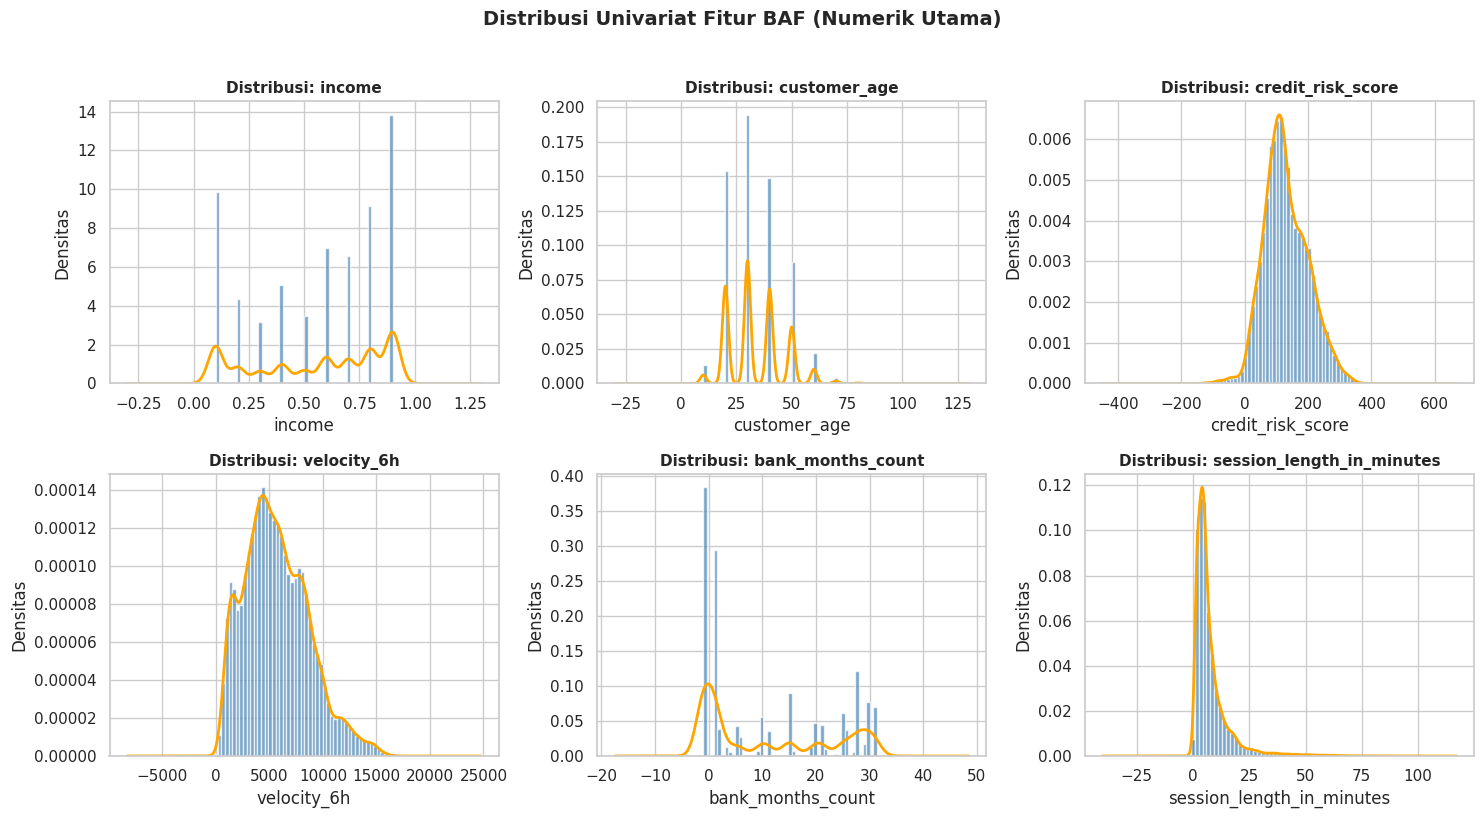

In [ ]:
# TAHAP 13 — DISTRIBUSI UNIVARIAT (Histogram + KDE)
n_cols = 3
n_rows = (len(kolom_num_utama) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(kolom_num_utama):
    data_clean = df[col].dropna()
    axes[i].hist(data_clean, bins=50, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    data_clean.sample(min(50000, len(data_clean)), random_state=42).plot(kind='kde', ax=axes[i], color='orange', lw=2)
    axes[i].set_title(f'Distribusi: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Densitas')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribusi Univariat Fitur BAF (Numerik Utama)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# TAHAP 13B — UJI NORMALITAS STATISTIK
print("\nH0: Data berdistribusi normal | p>0.05 NORMAL | p<=0.05 TIDAK NORMAL")
print("(Uji Shapiro-Wilk dan KS diuji pada sampel acak 5000 baris)\n")

hasil_normalitas = []
for col in kolom_num_utama:
    data_sample = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stat_sw, p_sw = shapiro(data_sample)
    stat_ks, p_ks = kstest(data_sample, 'norm', args=(data_sample.mean(), data_sample.std()))
    hasil_normalitas.append({
        'Fitur': col, 'Shapiro-Wilk p': round(p_sw,4), 'KS p': round(p_ks,4),
        'Normal?': '✅ Ya' if (p_sw > 0.05 and p_ks > 0.05) else '❌ Tidak'
    })
display(pd.DataFrame(hasil_normalitas))


H0: Data berdistribusi normal | p>0.05 NORMAL | p<=0.05 TIDAK NORMAL
(Uji Shapiro-Wilk dan KS diuji pada sampel acak 5000 baris)



,Fitur,Shapiro-Wilk p,KS p,Normal?
0,income,0.0000,0.0000,❌ Tidak
1,customer_age,0.0000,0.0000,❌ Tidak
2,credit_risk_score,0.0000,0.0000,❌ Tidak
3,velocity_6h,0.0000,0.0000,❌ Tidak
4,bank_months_count,0.0000,0.0000,❌ Tidak
5,session_length_in_minutes,0.0000,0.0000,❌ Tidak


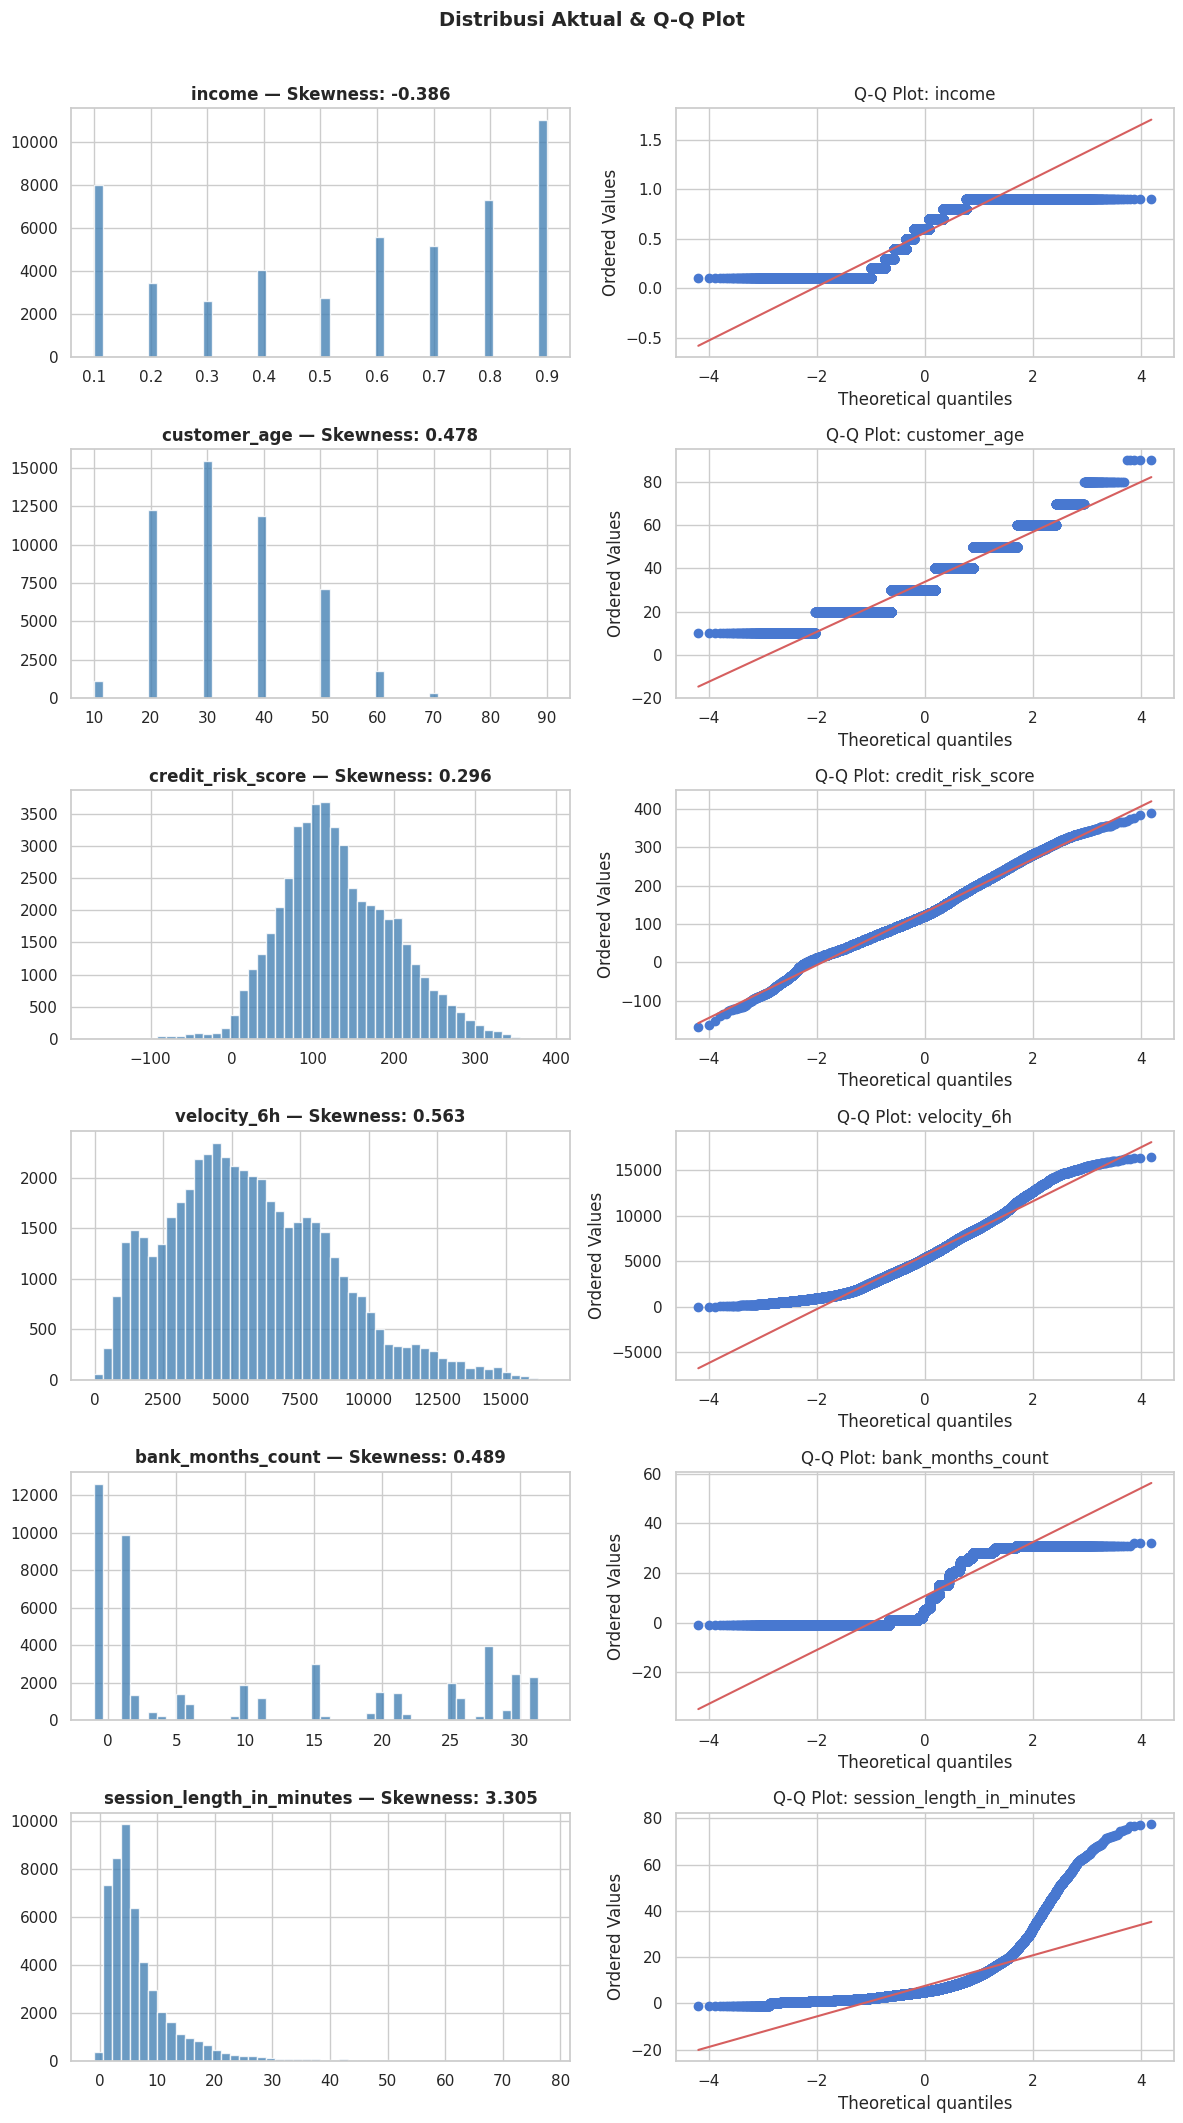

In [ ]:
# TAHAP 14 — CEK DISTRIBUSI MIRING (Q-Q Plot)
fig, axes = plt.subplots(len(kolom_num_utama), 2, figsize=(12, len(kolom_num_utama)*3.5))
for i, col in enumerate(kolom_num_utama):
    data_sample = df[col].dropna().sample(min(50000, len(df)), random_state=42)
    sk = df[col].skew()
    axes[i][0].hist(data_sample, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Skewness: {sk:.3f}', fontweight='bold')
    stats.probplot(data_sample, dist="norm", plot=axes[i][1])
    axes[i][1].set_title(f'Q-Q Plot: {col}')
plt.suptitle('Distribusi Aktual & Q-Q Plot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# TAHAP 15 — CEK DATA KOSONG (Missing Value Ringkasan)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({'Jumlah Kosong (NaN)': missing, 'Persentase (%)': missing_pct})
display(missing_df[missing_df['Jumlah Kosong (NaN)'] > 0])
print("\nTotal keseluruhan missing value (NaN) murni:", missing.sum())
print("💡 CATATAN: Peneliti NeurIPS merepresentasikan ketiadaan histori data menggunakan angka -1, bukan NaN.")

,Jumlah Kosong (NaN),Persentase (%)



Total keseluruhan missing value (NaN) murni: 0
💡 CATATAN BISNIS: Peneliti NeurIPS merepresentasikan ketiadaan histori data menggunakan angka -1, bukan NaN.


In [ ]:
# TAHAP 16 — LOKASI DATA KOSONG (Index Baris)
# ============================================================
if missing.sum() == 0:
    print("✅ Tidak ada kolom dengan data kosong (NaN)")

✅ Tidak ada kolom dengan data kosong (NaN) — tahap ekstraksi index dilewati.


In [ ]:
# TAHAP 17 — CEK DATA DUPLIKAT (Ringkasan)
jml_duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat identik: {jml_duplikat:,}")
print("Status:", "⚠️ Ada duplikat!" if jml_duplikat > 0 else "✅ Tidak ada duplikat")


Jumlah baris duplikat identik: 0
Status: ✅ Tidak ada duplikat


In [ ]:
# TAHAP 18 — LOKASI DATA DUPLIKAT
idx_duplikat = df[df.duplicated(keep='first')].index.tolist()
print("✅ Tidak ada data duplikat." if not idx_duplikat else f"Index duplikat (15 pertama): {idx_duplikat[:15]}")

✅ Tidak ada data duplikat.


In [ ]:
# TAHAP 19 — PENYESUAIAN TIPE DATA & KOREKSI VALUE INCONSISTENCY (-1)
print("\n🔍 Analisis Anomali Angka -1 (Makna Bisnis):")
# Mendeteksi fitur yang secara logis memiliki nilai -1 sebagai missing data
kolom_minus = [c for c in df.columns if df[c].dtype in ['int64', 'float64'] and (df[c] == -1).any()]
for c in kolom_minus:
    pct_minus = (df[c] == -1).mean() * 100
    print(f"📌 '{c}': {pct_minus:.2f}% data bernilai -1.")
print("💡 KEPUTUSAN: Nilai -1 dipertahankan secara utuh karena profil nasabah 'Tanpa Histori' memiliki kecenderungan risiko fraud yang berbeda.")


🔍 Analisis Anomali Angka -1 (Makna Bisnis):
📌 'prev_address_months_count': 71.29% data bernilai -1.
📌 'current_address_months_count': 0.43% data bernilai -1.
📌 'credit_risk_score': 0.05% data bernilai -1.
📌 'bank_months_count': 25.36% data bernilai -1.
📌 'session_length_in_minutes': 0.20% data bernilai -1.
📌 'device_distinct_emails_8w': 0.04% data bernilai -1.
💡 KEPUTUSAN: Nilai -1 dipertahankan secara utuh karena profil nasabah 'Tanpa Histori' memiliki kecenderungan risiko fraud yang berbeda.


In [ ]:
# TAHAP 20 — PERIKSA TIPE DATA SPESIFIK
print("\nRingkasan kolom per tipe data:")
ringkasan_tipe = {}
for col, dtype in df.dtypes.items():
    ringkasan_tipe.setdefault(str(dtype), []).append(col)
for dtype, cols in ringkasan_tipe.items():
    print(f"  {dtype:15s}: {len(cols)} kolom -> {cols[:4]}...")


Ringkasan kolom per tipe data:
  int64          : 18 kolom -> ['fraud_bool', 'prev_address_months_count', 'current_address_months_count', 'customer_age']...
  float64        : 9 kolom -> ['income', 'name_email_similarity', 'days_since_request', 'intended_balcon_amount']...
  object         : 5 kolom -> ['payment_type', 'employment_status', 'housing_status', 'source']...


In [ ]:
# TAHAP 21 — KONSISTENSI FORMAT KOLOM TANGGAL
# BAF merepresentasikan temporal dalam rentang 0 hingga 7 bulan operasional.
print(f"\n✅ Kolom waktu diekstraksi secara natural di BAF melalui fitur 'month'.")
print("Rentang operasi data (Bulan):", df['month'].min(), "sampai", df['month'].max())


✅ Kolom waktu diekstraksi secara natural di BAF melalui fitur 'month'.
Rentang operasi data (Bulan): 0 sampai 7


In [ ]:
# TAHAP 22 — IMPUTASI DATA KOSONG
print("✅ Dataset bersih. Teknik imputasi dilewati (Data -1 tetap dipertahankan).")


✅ Dataset bersih. Teknik imputasi dilewati (Data -1 tetap dipertahankan).


In [ ]:
# TAHAP 23 — DETEKSI OUTLIER (IQR & Z-SCORE)
cols_outlier = ['velocity_6h', 'velocity_24h', 'session_length_in_minutes', 'credit_risk_score']
hasil_outlier = []

for col in cols_outlier:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    bawah, atas = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out_iqr = ((data < bawah) | (data > atas)).sum()
    z_scores = np.abs(stats.zscore(data.sample(min(500000, len(data)), random_state=42)))
    out_z = (z_scores > 3).sum()

    hasil_outlier.append({
        'Fitur': col, 'Batas Bawah': round(bawah,2), 'Batas Atas': round(atas,2),
        'Outlier IQR': out_iqr, '% Outlier': round(out_iqr/len(data)*100,2),
        'Outlier Z-Score (500rb)': out_z
    })
print("\nDeteksi Anomali/Outlier:")
display(pd.DataFrame(hasil_outlier))


Deteksi Anomali/Outlier:


,Fitur,Batas Bawah,Batas Atas,Outlier IQR,% Outlier,Outlier Z-Score (500rb)
0,velocity_6h,-2930.1600,14047.2500,9005,0.9000,2191
1,velocity_24h,354.0900,8991.6700,2917,0.2900,308
2,session_length_in_minutes,-5.5400,17.5100,78789,7.8800,11790
3,credit_risk_score,-59.5000,320.5000,8729,0.8700,1875


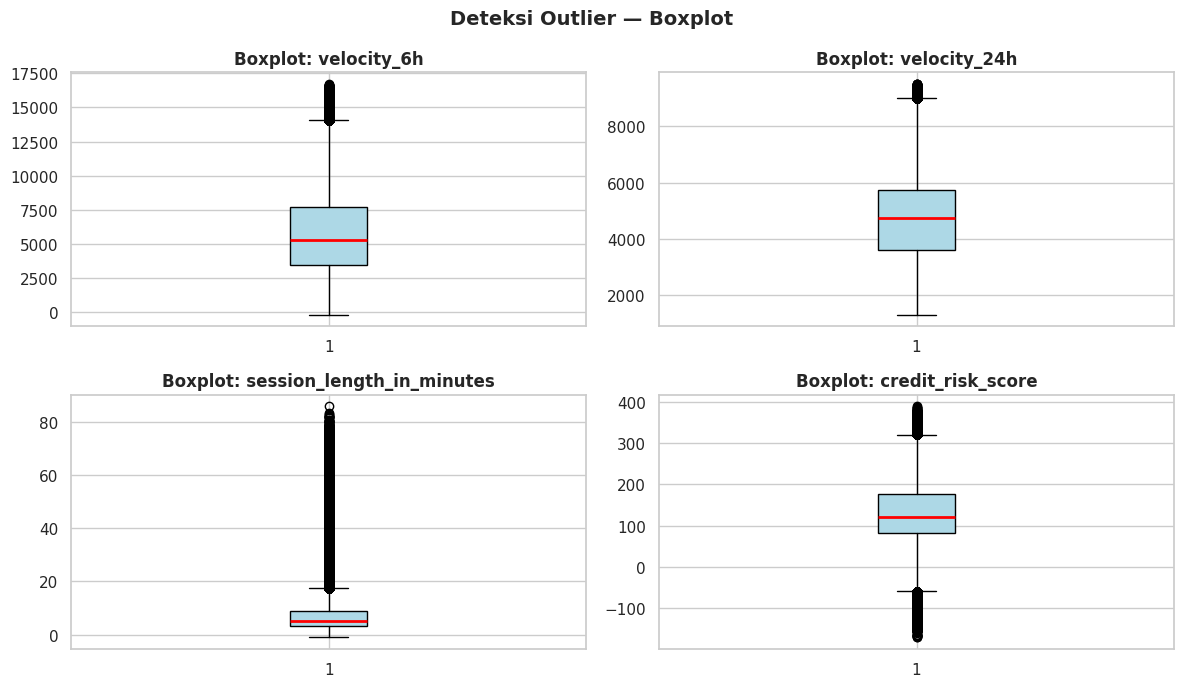

In [ ]:
# TAHAP 24 — VISUALISASI OUTLIER (Boxplot)
n_cols = 2
n_rows = (len(cols_outlier) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*3.5))
axes = axes.flatten()
for i, col in enumerate(cols_outlier):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('lightblue')
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
plt.suptitle('Deteksi Outlier — Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# TAHAP 25 — PENANGANAN OUTLIER
print("Outlier TIDAK dihapus. Kita mengaplikasikan log-transform pada fitur rentang lebar.")
df['velocity_6h_log'] = np.log1p(df['velocity_6h'])
print(f"Skewness 'velocity_6h' sebelum log     : {df['velocity_6h'].skew():.3f}")
print(f"Skewness 'velocity_6h_log' setelah log : {df['velocity_6h_log'].skew():.3f}")

💡 PENTING: Sama seperti prinsip di PaySim, perilaku ektrem (outlier) dalam jumlah transaksi/velocity adalah Sinyal Fraud.
Outlier TIDAK dihapus. Kita mengaplikasikan log-transform pada fitur rentang lebar.
Skewness 'velocity_6h' sebelum log     : 0.563
Skewness 'velocity_6h_log' setelah log : -1.025


In [ ]:
# TAHAP 26 — CORRELATION ANALYSIS (Pearson, Spearman, Kendall)
cols_corr = ['income', 'customer_age', 'credit_risk_score', 'velocity_6h', 'fraud_bool']
print("\n--- Pearson (populasi penuh) ---")
corr_pearson = df[cols_corr].corr(method='pearson')
display(corr_pearson.round(3))

df_sample_corr = df[cols_corr].sample(100000, random_state=42)
print("\n--- Spearman (sampel 100.000 baris) ---")
corr_spearman = df_sample_corr.corr(method='spearman')
display(corr_spearman.round(3))

print("\n--- Kendall (sampel 100.000 baris) ---")
corr_kendall = df_sample_corr.corr(method='kendall')
display(corr_kendall.round(3))


--- Pearson (populasi penuh) ---


,income,customer_age,credit_risk_score,velocity_6h,fraud_bool
income,1.0000,0.1260,0.1710,-0.0960,0.0450
customer_age,0.1260,1.0000,0.1660,-0.0220,0.0630
credit_risk_score,0.1710,0.1660,1.0000,-0.1450,0.0710
velocity_6h,-0.0960,-0.0220,-0.1450,1.0000,-0.0170
fraud_bool,0.0450,0.0630,0.0710,-0.0170,1.0000



--- Spearman (sampel 100.000 baris) ---


,income,customer_age,credit_risk_score,velocity_6h,fraud_bool
income,1.0000,0.1400,0.1740,-0.0970,0.0500
customer_age,0.1400,1.0000,0.1610,-0.0240,0.0590
credit_risk_score,0.1740,0.1610,1.0000,-0.1490,0.0610
velocity_6h,-0.0970,-0.0240,-0.1490,1.0000,-0.0220
fraud_bool,0.0500,0.0590,0.0610,-0.0220,1.0000



--- Kendall (sampel 100.000 baris) ---


,income,customer_age,credit_risk_score,velocity_6h,fraud_bool
income,1.0000,0.1100,0.1240,-0.0690,0.0440
customer_age,0.1100,1.0000,0.1190,-0.0180,0.0540
credit_risk_score,0.1240,0.1190,1.0000,-0.1000,0.0500
velocity_6h,-0.0690,-0.0180,-0.1000,1.0000,-0.0180
fraud_bool,0.0440,0.0540,0.0500,-0.0180,1.0000



📊 Crosstab Analisis: 'housing_status' x 'fraud_bool'


fraud_bool,0,1,Total
housing_status,,,
BA,163318,6357,169675
BB,259397,1568,260965
BC,369855,2288,372143
BD,25935,226,26161
BE,168553,582,169135
BF,1662,7,1669
BG,251,1,252
Total,988971,11029,1000000


fraud_bool,0,1
housing_status,,
BA,96.2500,3.7500
BB,99.4000,0.6000
BC,99.3900,0.6100
BD,99.1400,0.8600
BE,99.6600,0.3400
BF,99.5800,0.4200
BG,99.6000,0.4000


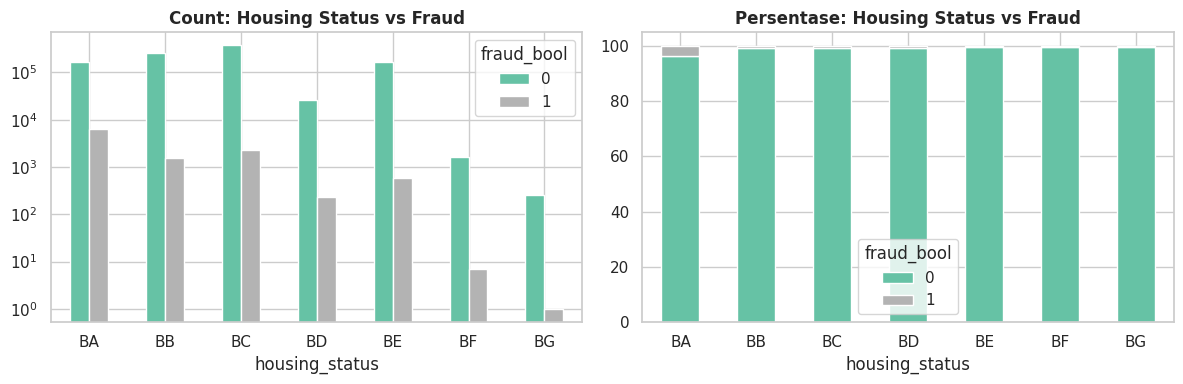

In [ ]:
# TAHAP 27 — CROSSTAB ANALYSIS (Kategorikal vs fraud_bool)
print("\n📊 Crosstab Analisis: 'housing_status' x 'fraud_bool'")
ct = pd.crosstab(df['housing_status'], df['fraud_bool'], margins=True, margins_name='Total')
display(ct)
ct_pct = pd.crosstab(df['housing_status'], df['fraud_bool'], normalize='index').round(4) * 100
display(ct_pct)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
ct.drop('Total', axis=0).drop('Total', axis=1).plot(kind='bar', ax=axes[0], colormap='Set2', rot=0)
axes[0].set_title('Count: Housing Status vs Fraud', fontweight='bold')
axes[0].set_yscale('log') # Skala log karena fraud sangat kecil
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', rot=0)
axes[1].set_title('Persentase: Housing Status vs Fraud', fontweight='bold')
plt.tight_layout(); plt.show()

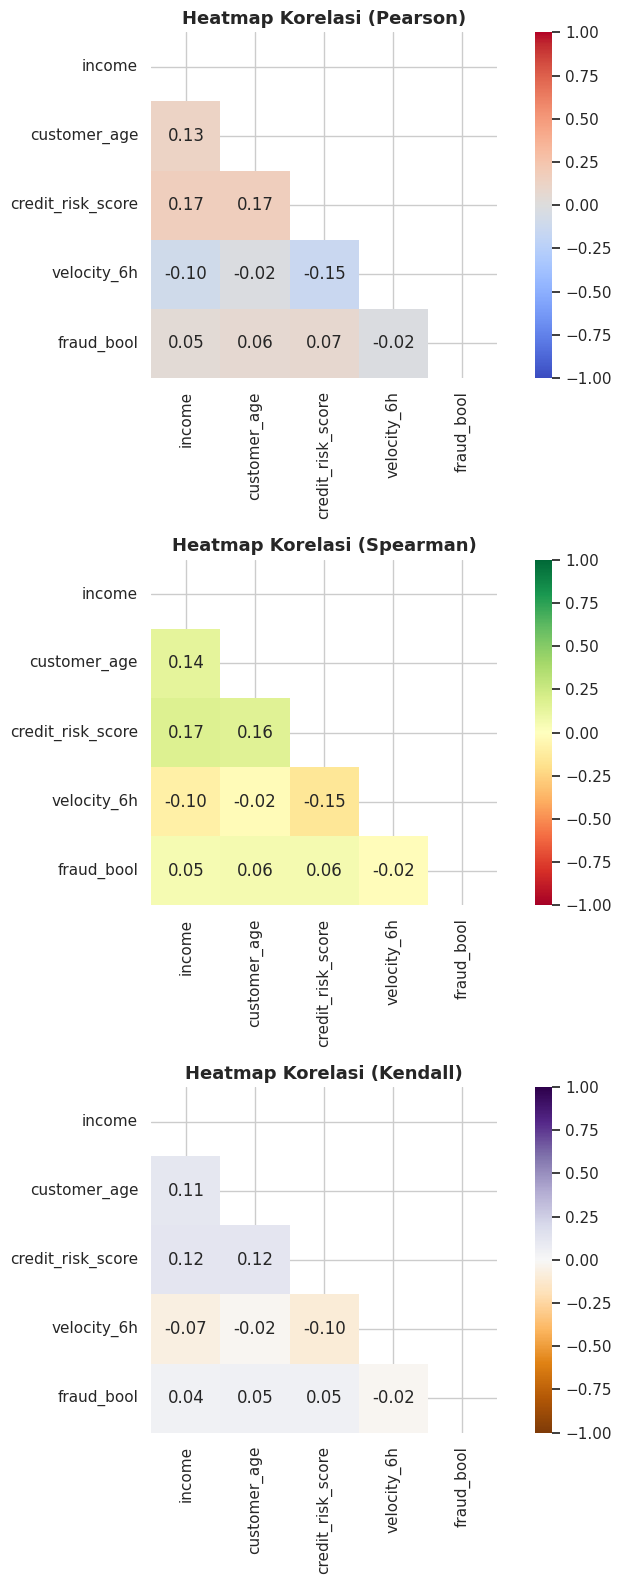

In [ ]:
# TAHAP 28 — HEATMAP CORRELATION
fig, axes = plt.subplots(3, 1, figsize=(8, 16))
metode_list = [('Pearson', corr_pearson, 'coolwarm'), ('Spearman', corr_spearman, 'RdYlGn'), ('Kendall', corr_kendall, 'PuOr')]
for ax, (nama, corr_mat, cmap) in zip(axes, metode_list):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-1, vmax=1, square=True)
    ax.set_title(f'Heatmap Korelasi ({nama})', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

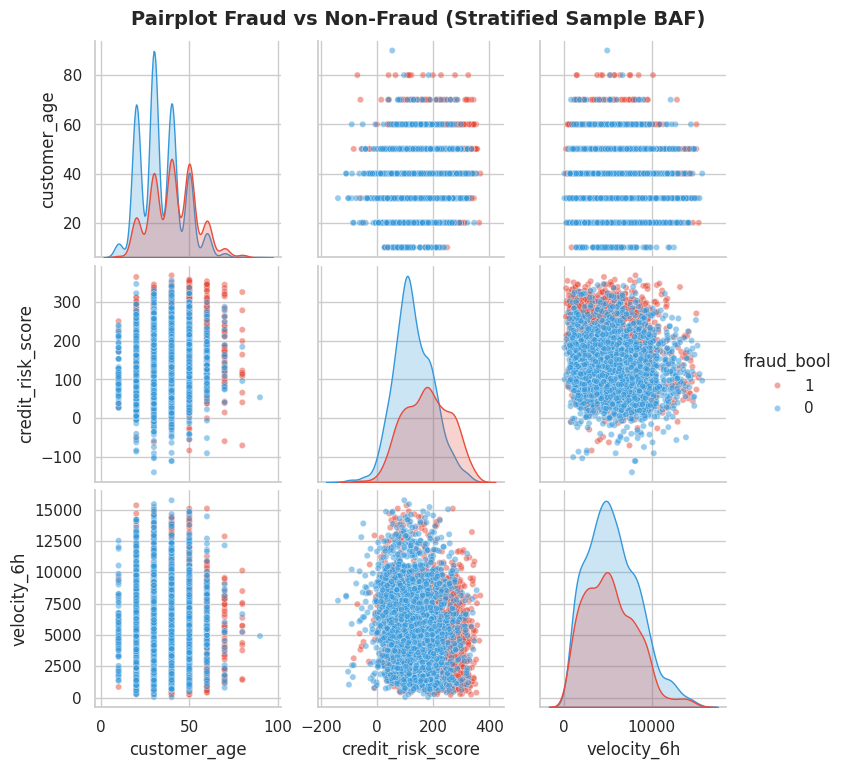

In [ ]:
# TAHAP 29 — PAIRPLOT (Stratified Sample)
# Karena fraud hanya 1.1%, stratified sample diwajibkan agar titik merah (fraud) terlihat
df_fraud = df[df['fraud_bool']==1].sample(min(2000, (df['fraud_bool']==1).sum()), random_state=42)
df_nonfraud = df[df['fraud_bool']==0].sample(3000, random_state=42)
df_pair = pd.concat([df_fraud, df_nonfraud])[['customer_age', 'credit_risk_score', 'velocity_6h', 'fraud_bool']].copy()
df_pair['fraud_bool'] = df_pair['fraud_bool'].astype(str)

pairplot = sns.pairplot(df_pair, hue='fraud_bool', diag_kind='kde', plot_kws={'alpha':0.5,'s':20}, palette={'0':'#3498db','1':'#e74c3c'})
pairplot.fig.suptitle('Pairplot Fraud vs Non-Fraud (Stratified Sample BAF)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

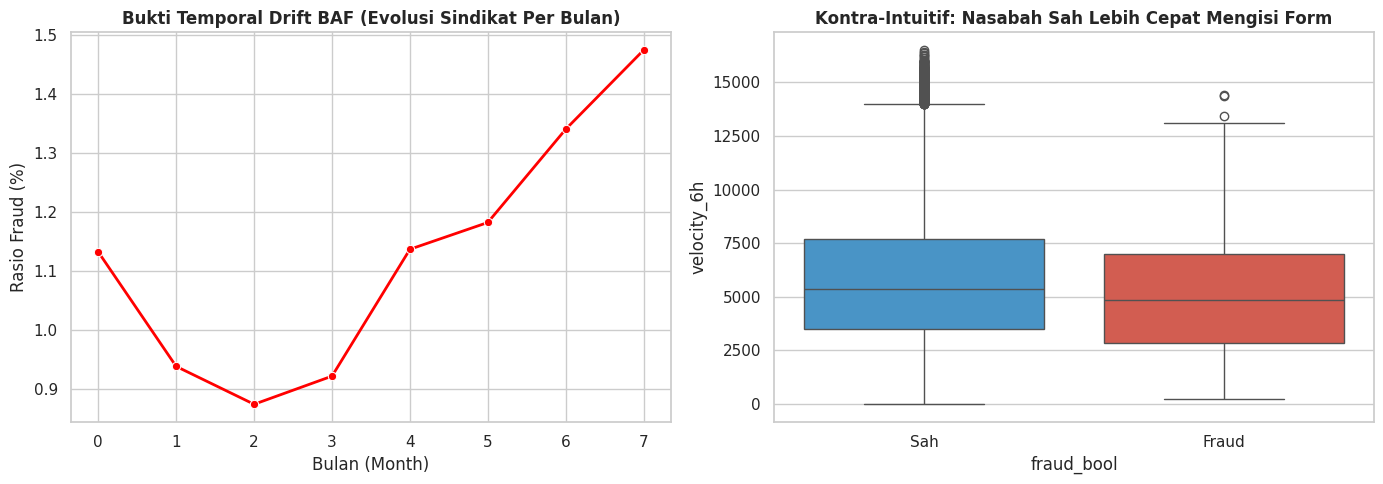

In [ ]:
# TAHAP 33A-F — VISUALISASI DATA TAMBAHAN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafik 1: Bukti Temporal Drift (Distribusi Penipuan Berdasarkan Bulan)
fraud_trend = df.groupby('month')['fraud_bool'].mean() * 100
sns.lineplot(x=fraud_trend.index, y=fraud_trend.values, marker='o', color='red', linewidth=2, ax=axes[0])
axes[0].set_title('Temporal Drift BAF (Evolusi Sindikat Per Bulan)', fontweight='bold')
axes[0].set_xlabel('Bulan (Month)'); axes[0].set_ylabel('Rasio Fraud (%)')

# Grafik 2: Kontra Intuitif Kecepatan Registrasi
sns.boxplot(data=df.sample(50000, random_state=42), x='fraud_bool', y='velocity_6h', palette=['#3498db', '#e74c3c'], ax=axes[1])
axes[1].set_title('Kontra-Intuitif: Nasabah Sah Lebih Cepat Mengisi Form', fontweight='bold')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Sah', 'Fraud'])
plt.tight_layout(); plt.show()

In [ ]:
# RINGKASAN AKHIR EDA
print("=" * 65)
print("             RINGKASAN AKHIR EDA - BAF NeurIPS 2022")
print("=" * 65)
print(f"   Dimensi dataset asli            : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"   Rasio Fraud                     : {df['fraud_bool'].mean()*100:.4f}% ({df['fraud_bool'].sum():,} Fraud)")
print("=" * 65)
print("Dataset siap dieksekusi dengan Machine Learning.")

             RINGKASAN AKHIR EDA - BAF NeurIPS 2022
   Dimensi dataset asli            : 1,000,000 baris x 33 kolom
   Rasio Fraud                     : 1.1029% (11,029 Fraud)
🎉 EDA selesai! Dataset siap dieksekusi dengan protokol Machine Learning Temporal.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

In [ ]:
# TAHAP 34: Feature Engineering (Memanfaatkan kode sentinel -1)
df_model = df.copy()
kolom_sentinel = ['prev_address_months_count', 'current_address_months_count',
                  'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']
for col in kolom_sentinel:
    df_model[f'{col}_ada_riwayat'] = (df_model[col] != -1).astype(int)

In [ ]:
# TAHAP 35: Pemisahan Temporal Wajib (Latih: Bulan 0-5, Uji: Bulan 6-7)
train_df = df_model[df_model['month'] <= 5].copy()
test_df  = df_model[df_model['month'] >= 6].copy()

In [ ]:
# TAHAP 36: One-Hot Encoding (Terpisah anti-leakage)
kolom_kategorikal_final = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
train_encoded = pd.get_dummies(train_df, columns=kolom_kategorikal_final, drop_first=True, dtype=int)
test_encoded  = pd.get_dummies(test_df, columns=kolom_kategorikal_final, drop_first=True, dtype=int)
test_encoded  = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

In [ ]:
# TAHAP 37: Memisahkan X (Fitur) dan y (Target)
TARGET_COL = 'fraud_bool'
fitur_final = [c for c in train_encoded.columns if c not in [TARGET_COL, 'month']]

X_train, y_train = train_encoded[fitur_final], train_encoded[TARGET_COL]
X_test, y_test   = test_encoded[fitur_final], test_encoded[TARGET_COL]

In [ ]:
# TAHAP 38: Scaling Data (StandardScaler)
kolom_non_dummy = [c for c in fitur_final if train_encoded[c].nunique() > 2]
COLS_SCALE = kolom_non_dummy

scaler = StandardScaler()
X_train[COLS_SCALE] = scaler.fit_transform(X_train[COLS_SCALE])
X_test[COLS_SCALE]  = scaler.transform(X_test[COLS_SCALE])

In [ ]:
# TAHAP 39: Melatih Algoritma Pemenang (HistGradientBoosting)
print("\n⏳ Melatih HistGradientBoostingClassifier...")
start_time = time.time()
hist_model = HistGradientBoostingClassifier(max_iter=200, class_weight='balanced', random_state=42)
hist_model.fit(X_train, y_train)
print(f"✅ Mesin selesai dilatih dalam {time.time() - start_time:.2f} detik!\n")


⏳ Melatih HistGradientBoostingClassifier...
✅ Mesin selesai dilatih dalam 42.52 detik!



🎯 Threshold 5% FPR        : 0.7869
🌟 Skor AUC Final          : 0.8902
🏆 RECALL (Tangkapan AI)   : 54.41%

📊 Rapor Klasifikasi Rinci:
              precision    recall  f1-score   support

           0     0.9932    0.9501    0.9712    202133
           1     0.1343    0.5441    0.2154      2878

    accuracy                         0.9444    205011
   macro avg     0.5638    0.7471    0.5933    205011
weighted avg     0.9812    0.9444    0.9606    205011



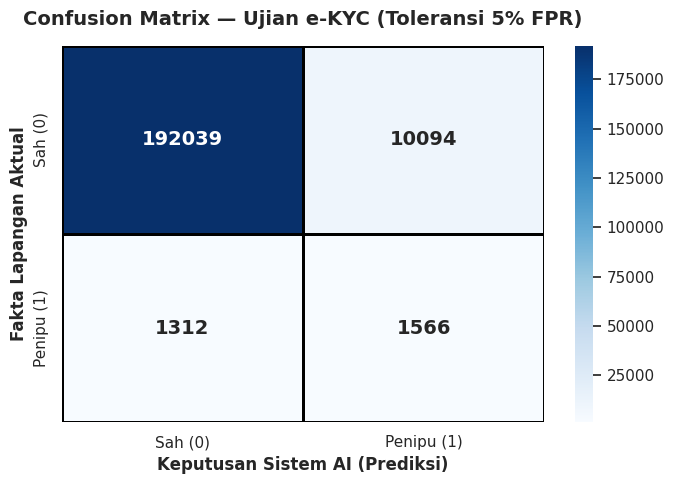


🚨 TAHAP 41: TEMUAN BESAR - AUDIT KEADILAN (FAIRNESS DISPARITY) 🚨


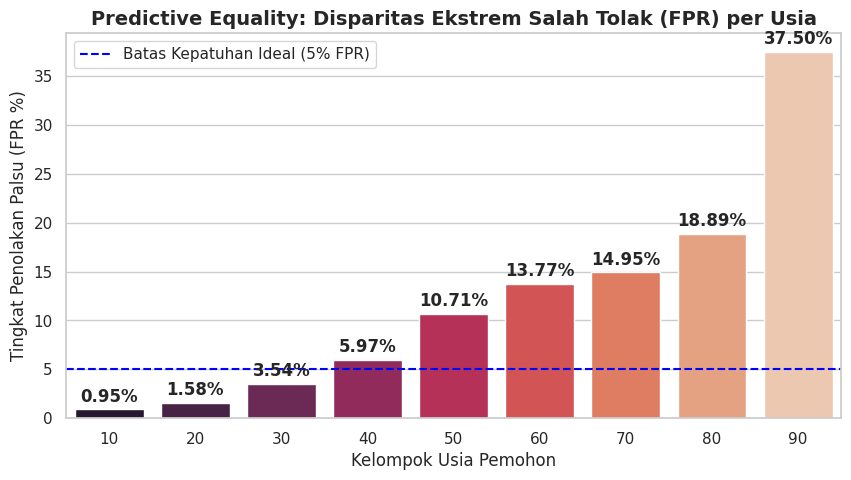


⚠️ RANGKUMAN DISPARITAS EKSTREM:
   - Salah Tolak Lansia (56+) : 21.28%
   - Salah Tolak Muda (18-25) : 1.58%
   -> AI Terbukti 13.5x lebih sering memblokir Lansia secara keliru!


In [ ]:
# TAHAP 40: Evaluasi Bisnis & Thresholding (Recall @ 5% FPR)
y_pred_proba = hist_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

idx_5_fpr = np.where(fpr <= 0.05)[0][-1]
threshold_bisnis = thresholds[idx_5_fpr]
recall_5_fpr = tpr[idx_5_fpr]

print(f"🎯 Threshold 5% FPR        : {threshold_bisnis:.4f}")
print(f"🌟 Skor AUC Final          : {auc_score:.4f}")
print(f"🏆 RECALL (Tangkapan AI)   : {recall_5_fpr * 100:.2f}%")

y_pred_bisnis = (y_pred_proba >= threshold_bisnis).astype(int)

# --- VISUALISASI 1: RAPOR & CONFUSION MATRIX ---
print("\n📊 Rapor Klasifikasi Rinci:")
print(classification_report(y_test, y_pred_bisnis, digits=4))

cm = confusion_matrix(y_test, y_pred_bisnis)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — Ujian e-KYC (Toleransi 5% FPR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Keputusan Sistem AI (Prediksi)', fontweight='bold')
plt.ylabel('Fakta Lapangan Aktual', fontweight='bold')
plt.xticks([0.5, 1.5], ['Sah (0)', 'Penipu (1)'])
plt.yticks([0.5, 1.5], ['Sah (0)', 'Penipu (1)'], va='center')
plt.tight_layout(); plt.show()

# --- VISUALISASI 2: FAIRNESS AUDIT ---
print("\n🚨 TAHAP 41: TEMUAN BESAR - AUDIT KEADILAN (FAIRNESS DISPARITY) 🚨")
df_eval = test_df.copy()
df_eval['fakta'] = y_test
df_eval['prediksi'] = y_pred_bisnis

pendaftar_sah = df_eval[df_eval['fakta'] == 0]
fpr_per_usia = pendaftar_sah.groupby('customer_age')['prediksi'].mean() * 100

plt.figure(figsize=(10, 5))
bar_plot = sns.barplot(x=fpr_per_usia.index, y=fpr_per_usia.values, palette="rocket")
plt.axhline(5, color='blue', linestyle='--', label='Batas Kepatuhan Ideal (5% FPR)')
plt.title('Predictive Equality: Disparitas Ekstrem Salah Tolak (FPR) per Usia', fontsize=14, fontweight='bold')
plt.xlabel('Kelompok Usia Pemohon'); plt.ylabel('Tingkat Penolakan Palsu (FPR %)')

for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.2f') + '%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.legend(); plt.show()

try:
    fpr_muda = fpr_per_usia.loc[20]
    fpr_lansia = fpr_per_usia.loc[fpr_per_usia.index >= 60].mean()
    print(f"\n⚠️ RANGKUMAN DISPARITAS EKSTREM:")
    print(f"   - Salah Tolak Lansia (56+) : {fpr_lansia:.2f}%")
    print(f"   - Salah Tolak Muda (18-25) : {fpr_muda:.2f}%")
    print(f"   -> AI Terbukti {fpr_lansia/fpr_muda:.1f}x lebih sering memblokir Lansia secara keliru!")
except:
    pass

In [ ]:
# TAHAP 42: Export untuk Streamlit
joblib.dump(hist_model, 'baf_histgb_model.pkl')
joblib.dump(scaler, 'baf_scaler.pkl')
joblib.dump(threshold_bisnis, 'baf_threshold.pkl')
joblib.dump(fitur_final, 'baf_cols_fs.pkl')
joblib.dump(COLS_SCALE, 'baf_cols_scale.pkl')
template_mentah = train_df.drop(columns=['fraud_bool', 'month']).median(numeric_only=True).to_dict()
joblib.dump(template_mentah, 'baf_template.pkl')

print("\n💾 PROSES SELESAI: 6 file (.pkl) berhasil diekspor")


💾 PROSES SELESAI: 6 file (.pkl) berhasil diekspor dan siap diunggah ke Streamlit!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000